# CircularCDSfold V1


In [50]:
%pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 1. 讀取 CSV 檔案
df_dn_beam = pd.read_csv("../LD_exact_2_target.csv")

# 2. 清理欄位名稱（去除前後多餘的空格）
df_dn_beam.columns = df_dn_beam.columns.str.strip()

# 3. 確保資料按 Protein length 排序，避免折線圖出現交叉亂線
df_dn_beam = df_dn_beam.sort_values(by="Protein length").reset_index(drop=True)

# 4. 計算 Run time + cRun time
df_dn_beam["Total time"] = df_dn_beam["Run time"] + df_dn_beam["cRun time"]

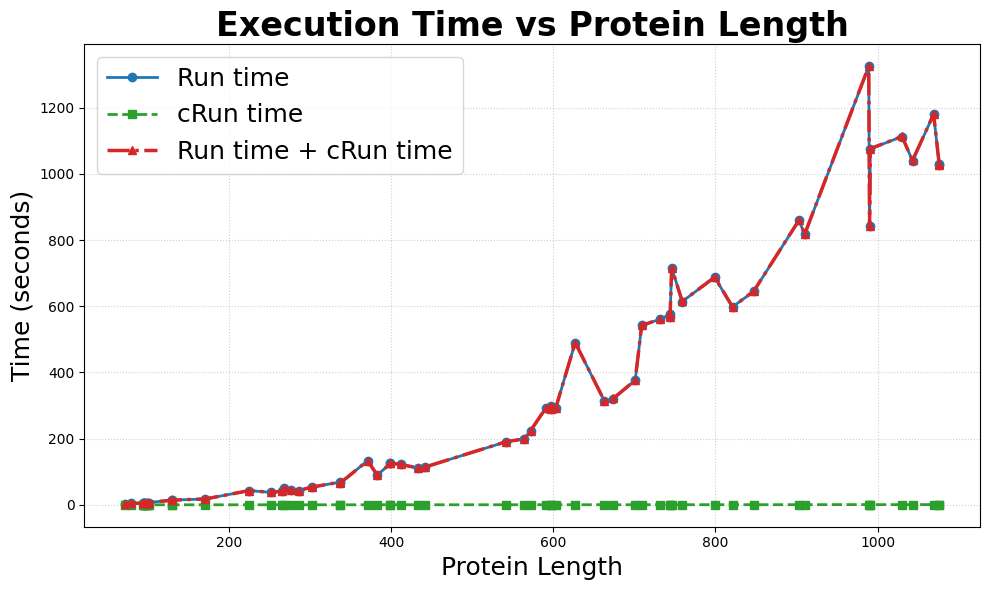

In [52]:
# ==========================================
# 繪製圖表 (X 軸: Length, Y 軸: Time)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# 繪製三條折線與數據點
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["Run time"],
    marker="o",
    linewidth=2,
    label="Run time",
    color="#1f77b4",
)

plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["cRun time"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="cRun time",
    color="#2ca02c",
)

plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["Total time"],
    marker="^",
    linewidth=2.5,
    linestyle="-.",
    label="Run time + cRun time",
    color="#d62728",
)

# 設定圖表標題與軸標籤
plt.title("Execution Time vs Protein Length", fontsize=24, fontweight="bold")
plt.xlabel("Protein Length", fontsize=18)
plt.ylabel("Time (seconds)", fontsize=18)

# 增加網格線與圖例
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=18, loc="upper left")

# 調整佈局並顯示
plt.tight_layout()
plt.show()

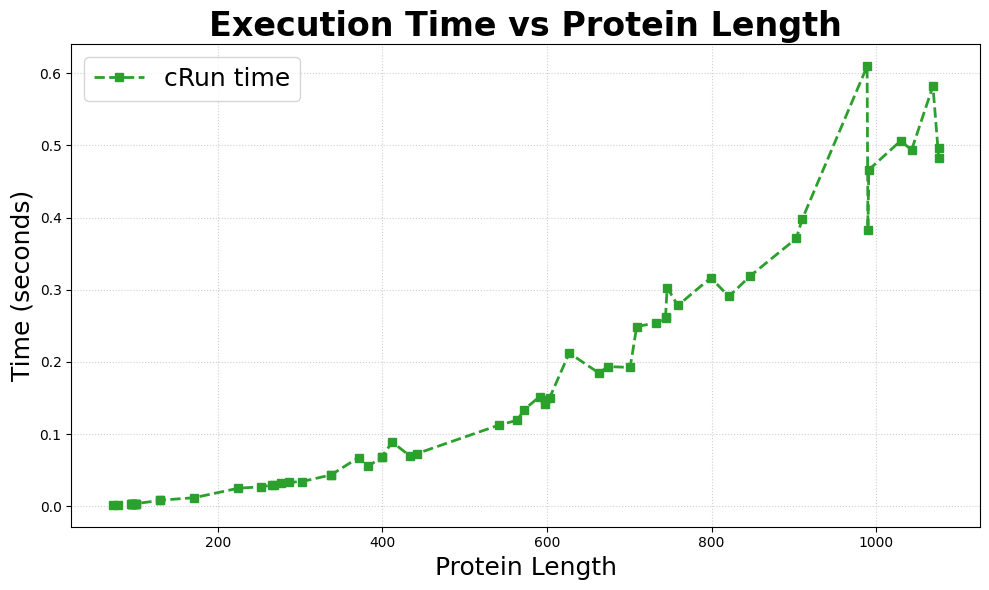

In [53]:
# ==========================================
# 繪製圖表 (X 軸: Length, Y 軸: Time)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# 繪製三條折線與數據點
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["cRun time"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="cRun time",
    color="#2ca02c",
)

# 設定圖表標題與軸標籤
plt.title("Execution Time vs Protein Length", fontsize=24, fontweight="bold")
plt.xlabel("Protein Length", fontsize=18)
plt.ylabel("Time (seconds)", fontsize=18)

# 增加網格線與圖例
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=18, loc="upper left")

# 調整佈局並顯示
plt.tight_layout()
plt.show()

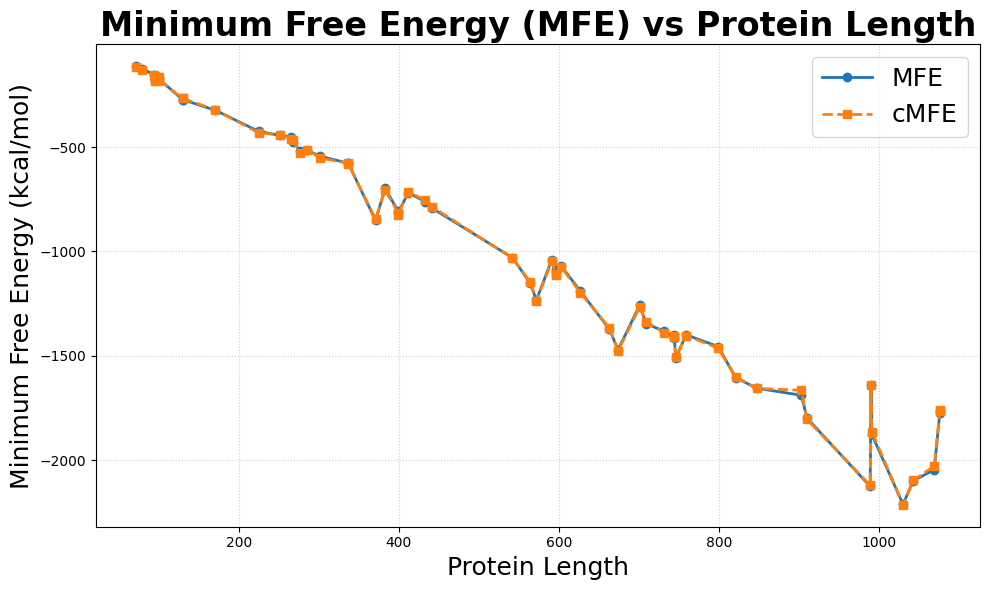

In [54]:
# ==========================================
# 繪製圖表 (X 軸: Length, Y 軸: MFE / cMFE)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# 繪製 MFE 折線
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["MFE"],
    marker="o",
    linewidth=2,
    label="MFE",
    color="#1f77b4",  # 藍色
)

# 繪製 cMFE 折線
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["cMFE"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="cMFE",
    color="#ff7f0e",  # 橘色
)

# 設定圖表標題與軸標籤
plt.title(
    "Minimum Free Energy (MFE) vs Protein Length",
    fontsize=24,
    fontweight="bold",
)
plt.xlabel("Protein Length", fontsize=18)
plt.ylabel("Minimum Free Energy (kcal/mol)", fontsize=18)

# 增加網格線與圖例
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=18, loc="best")

# 調整佈局並顯示
plt.tight_layout()
plt.show()

In [55]:
# 確保欄位名稱正確（帶前導空格）
len_col = "Protein length"
mfe_col = "MFE"
cmfe_col = "cMFE"

# ==========================================
# 1. 計算自由能密度比值 (MFE Density Ratio) -> 推薦科學文獻寫法
# ==========================================
# 算每條序列的 MFE Density，再取算術平均
mfe_density_exact = np.mean(df_dn_beam[mfe_col] / df_dn_beam[len_col])
mfe_density_circ = np.mean(df_dn_beam[cmfe_col] / df_dn_beam[len_col])

mfe_density_ratio = mfe_density_exact / mfe_density_circ

# ==========================================
# 輸出計算結果
# ==========================================
print("========== MFE 穩定度對比計算結果 ==========")
print(f"DN_exact 的平均 MFE 密度 (MFE/Length): {mfe_density_exact:.4f}")
print(f"DN_circ  的平均 MFE 密度 (MFE/Length): {mfe_density_circ:.4f}")
print(f"最終 MFE 密度比值 (MFE Density Ratio) : {mfe_density_ratio:.4f}")
print("============================================")

# 生物學解釋 (注意：MFE 是負值，越負代表結構越穩定)
print("\n💡 生物學熱力學解釋：")
if mfe_density_exact < mfe_density_circ:
    percentage = (1 - mfe_density_ratio) * 100
    print(
        f"   DN_exact 的 MFE 密度較低（更負），意味著在相同長度下，\n"
        f"   DN_exact 設計的 RNA 結構比 DN_circ 更穩定，穩定度高出約 {percentage:.1f}%。"
    )
elif mfe_density_exact > mfe_density_circ:
    percentage = (mfe_density_ratio - 1) * 100
    print(
        f"   DN_circ 的 MFE 密度較低（更負），意味著在相同長度下，\n"
        f"   DN_circ 設計的 RNA 結構比 DN_exact 更穩定！\n"
        f"   DN_exact 的結構穩定度只有 DN_circ 的 {mfe_density_ratio:.2f} 倍。"
    )
else:
    print("   兩個資料集的整體 MFE 結構穩定度高度一致。")

========== MFE 穩定度對比計算結果 ==========
DN_exact 的平均 MFE 密度 (MFE/Length): -1.8594
DN_circ  的平均 MFE 密度 (MFE/Length): -1.8676
最終 MFE 密度比值 (MFE Density Ratio) : 0.9957

💡 生物學熱力學解釋：
   DN_circ 的 MFE 密度較低（更負），意味著在相同長度下，
   DN_circ 設計的 RNA 結構比 DN_exact 更穩定！
   DN_exact 的結構穩定度只有 DN_circ 的 1.00 倍。


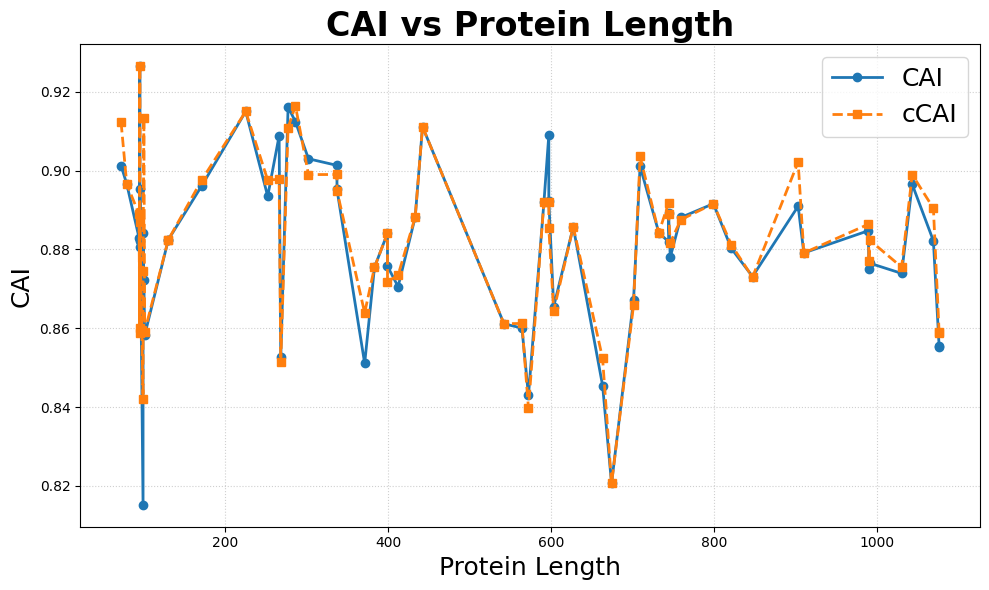

In [56]:
# ==========================================
# 繪製圖表 (X 軸: Length, Y 軸: CAI / cCAI)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# 繪製 CAI 折線
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["CAI"],
    marker="o",
    linewidth=2,
    label="CAI",
    color="#1f77b4",  # 藍色
)

# 繪製 cCAI 折線
plt.plot(
    df_dn_beam["Protein length"],
    df_dn_beam["cCAI"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="cCAI",
    color="#ff7f0e",  # 橘色
)

# 設定圖表標題與軸標籤
plt.title(
    "CAI vs Protein Length",
    fontsize=24,
    fontweight="bold",
)
plt.xlabel("Protein Length", fontsize=18)
plt.ylabel("CAI", fontsize=18)

# 增加網格線與圖例
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=18, loc="best")

# 調整佈局並顯示
plt.tight_layout()
plt.show()

In [57]:
# 1. 定義帶有前導空格的欄位名稱
len_col = "Protein length"
cai_col = "CAI"
ccai_col = "cCAI"

# 2. 計算 DN_exact 的分子：Sum(長度 * log(CAI)) 以及總長度
# 這裡使用 np.log() 計算自然對數 (ln)
sum_len_log_cai_exact = np.sum(df_dn_beam[len_col] * np.log(df_dn_beam[cai_col]))
total_length_exact = np.sum(df_dn_beam[len_col])

# 計算 DN_exact 長度加權後的平均 log(CAI)
mean_log_cai_exact = sum_len_log_cai_exact / total_length_exact


# 3. 計算 DN_circ 的分子：Sum(長度 * log(CAI)) 以及總長度
sum_len_log_cai_circ = np.sum(
    df_dn_beam[len_col] * np.log(df_dn_beam[ccai_col])
)
total_length_circ = np.sum(df_dn_beam[len_col])

# 計算 DN_circ 長度加權後的平均 log(CAI)
mean_log_cai_circ = sum_len_log_cai_circ / total_length_circ


# 4. 計算兩個資料集之間的對數差值 (Log_Diff)
log_diff = mean_log_cai_exact - mean_log_cai_circ

# 5. 透過指數函數 (np.exp) 將對數差值還原，得到幾何平均數比值 (Geometric Ratio)
geometric_ratio = np.exp(log_diff)


# ==========================================
# 輸出計算結果
# ==========================================
print("========== 幾何平均數比值 (Geometric Ratio) 計算結果 ==========")
print(f"DN_exact 的長度加權平均 log(CAI): {mean_log_cai_exact:.6f}")
print(f"DN_circ  的長度加權平均 log(CAI): {mean_log_cai_circ:.6f}")
print(f"對數差值 (Log_Diff)            : {log_diff:.6f}")
print("-" * 62)
print(f"最終幾何比值 (Geometric Ratio)  : {geometric_ratio:.4f}")
print("==============================================================")

# 自動根據比值給出直觀的生物學解釋
if geometric_ratio > 1:
    percentage = (geometric_ratio - 1) * 100
    print(
        f"💡 解釋：從密碼子連乘（幾何平均）的角度來看，\n"
        f"   DN_exact 的整體 CAI 表現優於 DN_circ，約為 DN_beam 的 {geometric_ratio:.4f} 倍（高出 {percentage:.1f}%）。"
    )
elif geometric_ratio < 1:
    percentage = (1 - geometric_ratio) * 100
    inverse_ratio = 1 / geometric_ratio
    print(
        f"💡 解釋：從密碼子連乘（幾何平均）的角度來看，\n"
        f"   DN_circ 的整體 CAI 表現優於 DN_exact！\n"
        f"   DN_circ 約為 DN_exact 的 {inverse_ratio:.4f} 倍（DN_exact 相對低了 {percentage:.1f}%）。"
    )
else:
    print("💡 解釋：兩個資料集的整體幾何平均 CAI 完全相同。")

========== 幾何平均數比值 (Geometric Ratio) 計算結果 ==========
DN_exact 的長度加權平均 log(CAI): -0.129315
DN_circ  的長度加權平均 log(CAI): -0.127727
對數差值 (Log_Diff)            : -0.001588
--------------------------------------------------------------
最終幾何比值 (Geometric Ratio)  : 0.9984
💡 解釋：從密碼子連乘（幾何平均）的角度來看，
   DN_circ 的整體 CAI 表現優於 DN_exact！
   DN_circ 約為 DN_exact 的 1.0016 倍（DN_exact 相對低了 0.2%）。


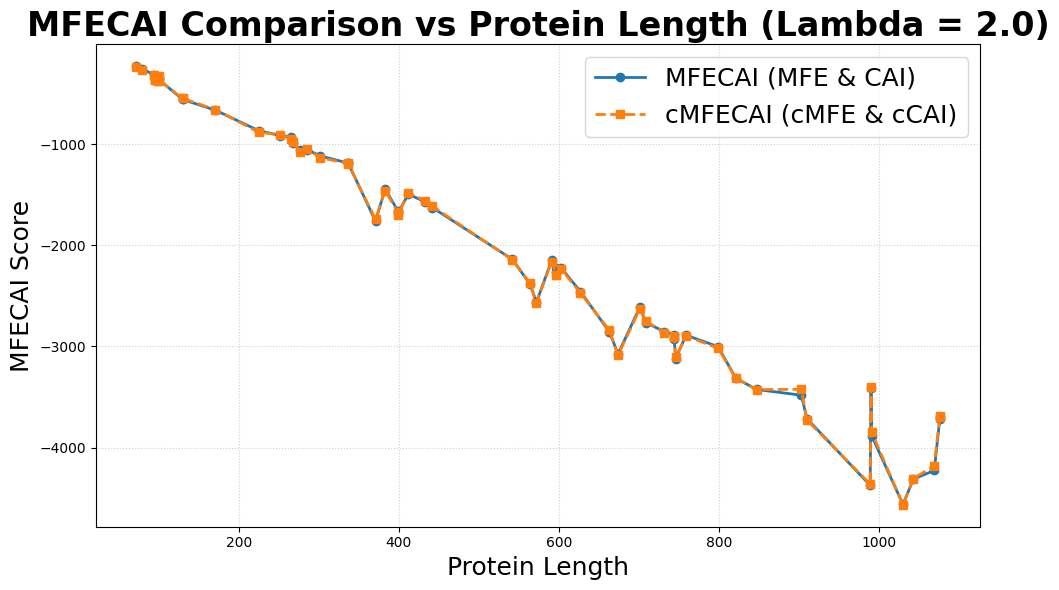

In [58]:
# 2. 設定 Lambda 參數 (請根據需求調整，例如 0.5 或從資料集的 Lambda 欄位讀取)
# 若資料集中已有 Lambda 欄位，可改為 lambda_val = df_dn_beam['Lambda']
lambda_val = df_dn_beam["Lambda"][0]

# 3. 計算 MFE/CAI 的 MFECAI 分數
cai_log = np.log(df_dn_beam["CAI"])
df_dn_beam["MFECAI"] = lambda_val * df_dn_beam["MFE"] - (1 - lambda_val) * (df_dn_beam["Protein length"] * cai_log)

# 4. 計算 cMFE/cCAI 的 cMFECAI 分數
c_cai_log = np.log(df_dn_beam["cCAI"])
df_dn_beam["cMFECAI"] = lambda_val * df_dn_beam["cMFE"] - (1 - lambda_val) * (df_dn_beam["Protein length"] * c_cai_log)

# 5. 按長度排序以便繪圖
df_dn_beam = df_dn_beam.sort_values(by="Protein length").reset_index(drop=True)

# ==========================================
# 輸出前幾筆計算結果
# ==========================================
# print(df_dn_beam[['UniPort ID', 'Protein length', 'MFECAI', 'cMFECAI']])

# ==========================================
# 繪製 MFECAI 與 cMFECAI 對比圖
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

plt.plot(df_dn_beam["Protein length"], df_dn_beam["MFECAI"], marker='o', linewidth=2, label="MFECAI (MFE & CAI)", color="#1f77b4")
plt.plot(df_dn_beam["Protein length"], df_dn_beam["cMFECAI"], marker='s', linewidth=2, linestyle="--", label="cMFECAI (cMFE & cCAI)", color="#ff7f0e")

plt.title(f"MFECAI Comparison vs Protein Length (Lambda = {lambda_val})", fontsize=24, fontweight="bold")
plt.xlabel("Protein Length", fontsize=18)
plt.ylabel("MFECAI Score", fontsize=18)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()